In [14]:
from synthetic_data import distributions, generate_sample_csv
import matplotlib.pyplot as plt

## Sahoo-et-al Model Synthetic Data

In [15]:
def predator_prey_model(y, t, params):
    X, Y = y
    rho, K, kappa1, kappa2, theta = params
    ddt_X = rho * X * (1 - X / K) - kappa1 * X * Y
    ddt_Y = kappa2 * X * Y - theta * Y
    return [ddt_X, ddt_Y]

In [16]:
# n_indivs = 15
# n_obs = 10
# max_day_number = 300
# err_b = 0.001
# pop_param_info = [
#     ("rho", 0.06, 0, distributions["lognormal"]),
#     ("K", 1e9, 0.2, distributions["lognormal"]),
#     # ("K", 1e9, 0, distributions["lognormal"]),
#     # ("kappa1", 6e-9, 0.2, distributions["lognormal"]),
#     ("kappa1", 6e-9, 0, distributions["lognormal"]),
#     # ("kappa2", 0.3e-10, 0.3e-11, distributions["normal"]),
#     ("kappa2", 0.3e-10, 0, distributions["normal"]),
#     # ("theta", 0.1e-5, 1.0, distributions["lognormal"]),
#     ("theta", 0.1e-5, 0, distributions["lognormal"]),
# ]
# obs_var_info = [
#     # ("X", 1.3e8, 0.2, distributions["lognormal"], "combined1", distributions["normal"]),
#     ("X", 1.3e8, 0, distributions["lognormal"], "combined1", distributions["normal"]),
#     # ("Y", 7e6, 0.2, distributions["lognormal"], "combined1", distributions["normal"]),
#     ("Y", 7e6, 0, distributions["lognormal"], "combined1", distributions["normal"]),
# ]
# obs_times_all, observations_all, _ = generate_sample_csv(
#     # f"sahoo1_n{n_indivs}_o{n_obs}_d{max_day_number}",
#     f"sahoo_only_rho",
#     predator_prey_model,
#     pop_param_info,
#     obs_var_info,
#     n_indivs,
#     n_obs,
#     max_day_number=300,
#     err_a=0,
#     err_b=err_b,
# )

In [17]:
# for times, obs in zip(obs_times_all, observations_all):
#     plt.figure(figsize=(3, 3))
#     plt.plot(times, obs[0], label="cancer")
#     plt.plot(times, obs[1], label="CAR-T")
#     plt.legend()
#     plt.show()

## Liu-et-al Model Synthetic Data

### 4 models from Paper

In [18]:
def cd19_b_all_cell(np_cells, nTA, params):
    """
    Calculates the derivative of CD19⁺ B-ALL cells.
    """
    r_p, n_c, e, K_p = params
    dnp_dt = r_p * (1 - np_cells / n_c) * np_cells - e * (np_cells / (np_cells + K_p)) * nTA
    return dnp_dt

def cart_activation(np_cells, nTA, nTN, params):
    """
    Calculates the derivative of activated CAR T-cells.
    """
    r_TA, K_r, k_A, K_A, l_TA = params
    dnTA_dt = r_TA * (np_cells / (np_cells + K_r)) * nTA + k_A * (np_cells / (np_cells + K_A)) * nTN - l_TA * nTA
    return dnTA_dt

def non_activated(np_cells, nTN, params):
    """
    Calculates the derivative of non-activated CAR T-cells.
    """
    k_A, K_A, l_TN = params
    dnTN_dt = -k_A * (np_cells / (np_cells + K_A)) * nTN - l_TN * nTN
    return dnTN_dt

def relapse(np_cells, nN, nTA, params):
    """
    Calculates the derivative of CD19⁻ tumor cells.
    """
    r_N, n_c, k_m, e, k_b, K_N = params
    if k_b == 0:
        term = 0
    else:
        term = (e / k_b) * (nN / (nN + K_N)) * nTA
    dnN_dt = r_N * (1 - nN / n_c) * nN + k_m * np_cells - term
    return dnN_dt


def car_t_cell_model(y, t, params):
    np_cells, nTA, nTN, nN = y
    
    # Unpack parameters for each function
    # [r_p, n_c, e, K_p]
    params_cd19 = params[:4]
    # [r_TA, K_r, k_A, K_A, l_TA]
    params_activation = params[4:9]
    # [k_A, K_A, l_TN]
    params_non_activated = [params[6], params[7], params[9]]
    # [r_N, n_c, k_m, e, k_b, K_N]
    params_relapse = params[10:]
    
    # Compute each derivative
    dnp_dt = cd19_b_all_cell(np_cells, nTA, params_cd19)
    dnTA_dt = cart_activation(np_cells, nTA, nTN, params_activation)
    dnTN_dt = non_activated(np_cells, nTN, params_non_activated)
    dnN_dt = relapse(np_cells, nN, nTA, params_relapse)
    
    return [dnp_dt, dnTA_dt, dnTN_dt, dnN_dt]

In [19]:
n_indivs = 15
n_obs = 10
max_day_number = 300
err_a = 0.0
err_b = 0.001

pop_param_info_cr = [
    ("r_p",    0.069,    0.3, distributions["lognormal"]),
    ("n_c",    2939.1,   0.3, distributions["lognormal"]),
    ("e",      22.72,    0.3, distributions["lognormal"]),
    ("K_p",    5891.5,   0.3, distributions["lognormal"]),
    ("r_TA",   1.62,     0.3, distributions["lognormal"]),
    ("K_r",    637.64,   0.3, distributions["lognormal"]),
    ("k_A",    0.65,     0.3, distributions["normal"]),
    ("K_A",    1808.0,   0.3, distributions["lognormal"]),
    ("l_TA",   0.12,     0.3, distributions["lognormal"]),
    ("l_TN",   3e-5,     0.3, distributions["normal"]),
    ("r_N",    0,        0.3, distributions["normal"]),
    ("n_c2",   2939.1,   0.3, distributions["lognormal"]),  # Duplicate n_c for relapse
    ("k_m",    0,        0.3, distributions["normal"]),
    ("e2",     22.72,    0.3, distributions["lognormal"]),  # Duplicate e for relapse
    ("k_b",    0,        0.3, distributions["normal"]),
    ("K_N",    0,        0.3, distributions["normal"]),
]

# Can change "exact" to log10

obs_var_info_cr = [
    ("np_cells", 2200.24, 0.2, distributions["lognormal"], "combined1", 0, 0, 1, distributions["normal"], "nonnegative"),
    ("nTA",      0,       0.2, distributions["normal"],    "combined1", 0, 0, 1, distributions["normal"], "nonnegative"),
    ("nTN",      16.5,    0.2, distributions["lognormal"], "combined1", 0, 0, 1, distributions["normal"], "nonnegative"),
    ("nN",       0,       0.2, distributions["normal"],    "combined1", 0, 0, 1, distributions["normal"], "nonnegative"),
]


obs_times_all, observations_all, obs_dict = generate_sample_csv(
    save_name="liu_et_al",
    model=car_t_cell_model,
    pop_param_info=pop_param_info_cr,
    obs_var_info=obs_var_info_cr,
    n_indivs=n_indivs,
    n_obs=n_obs,
    max_day_number=max_day_number,
    seed=42
)

print("Synthetic data generated and saved as liu_et_al.csv")

 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.4291611797456D-01   r2 =  0.1908300679935D-17
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.4291611797456D-01   r2 =  0.1908300679935D-17
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.4291611797456D-01   r2 =  0.3378845270176D-17
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.4291611797456D-01   r2 =  0.1815912526050D-17
 lsoda--  warning..internal t (=r1) 

/Users/rohanpandey/Desktop/Research_Projects/CARTCell Research/CAR-T-Cell/Monolix/synthetic_data.py:145: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  odeint(model, initial_conditions, times, args=(params,)).T


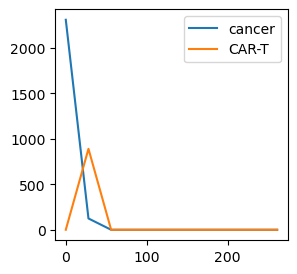

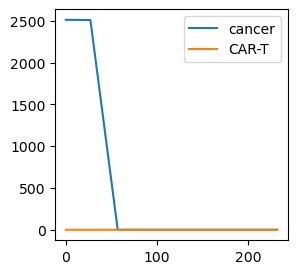

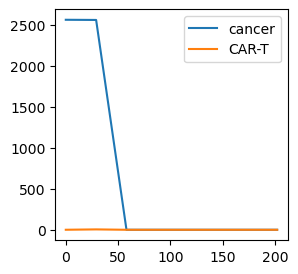

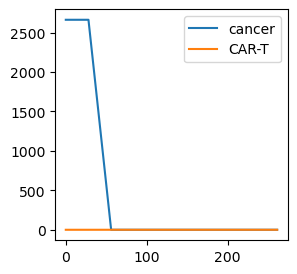

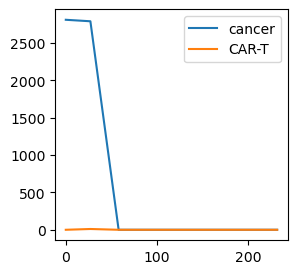

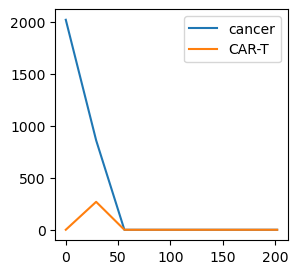

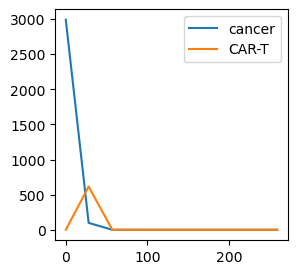

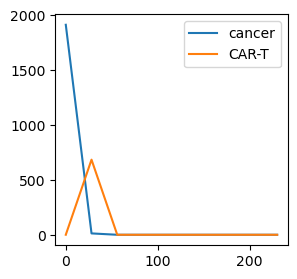

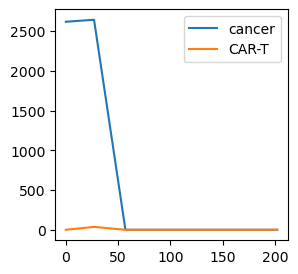

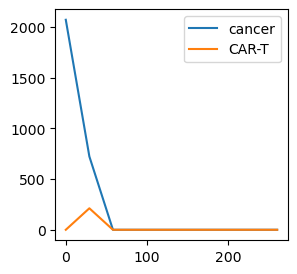

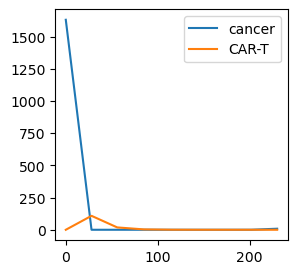

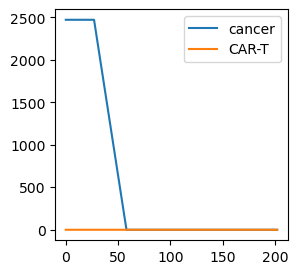

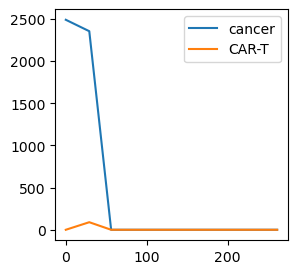

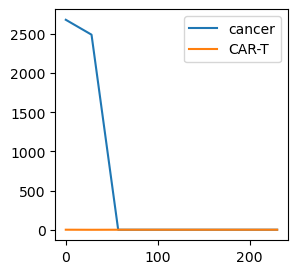

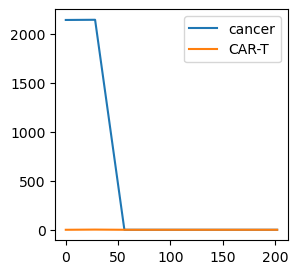

In [20]:
for times, obs in zip(obs_times_all, observations_all):
    plt.figure(figsize=(3, 3))
    plt.plot(times, obs[0], label="cancer")
    plt.plot(times, obs[1], label="CAR-T")
    plt.legend()
    plt.show()